In [31]:
import sys
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions

plt.rcParams.update({'font.size': 12})

if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PyMPDATA-examples')


In [32]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, options: Options = None, bathymetry: np.ndarray, vh_initial: np.ndarray, uh_initial: np.ndarray):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)

        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid, n_threads=1)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0), boundary_conditions.Constant(value=0)],
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(uh_initial, **kwargs),
            "vh": ScalarField(vh_initial, **kwargs),
        }
        self.advector = VectorField((
            np.zeros((grid[X] + 1, grid[Y])),
            np.zeros((grid[X], grid[Y] + 1))
        ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }
        self.bathymetry = bathymetry
        self.max_courant_numbers = []

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()

    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        all = slice(None, None)
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[(
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1
        return np.amax(np.abs(courant_number))

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output


In [33]:
def run_wave_simulation(grid, bathymetry, nt, dt_over_dxy, outfreq, eps):
    g = 10.0
    safe_eps = max(eps, 0.005)

    bathymetry = np.maximum(bathymetry, safe_eps)

    h_initial = bathymetry.copy()
    vh_initial = np.zeros(grid)
    uh_initial = np.zeros(grid)


    mu = grid[1] * 0.85
    width_param = grid[1] / 25.0
    amplitude = 0.1 
    
    Y = np.arange(grid[1])
    eta = amplitude * (1.0 / np.cosh((Y - mu) / width_param))**2
    
    eta[eta < 1e-10] = 0.0
    
    h_initial += eta[np.newaxis, :]
    

    h_total_line = h_initial[0, :]
    u_magnitude = eta * np.sqrt(g / h_total_line)
    u_velocity = -u_magnitude
    vh_initial += (h_total_line * u_velocity)[np.newaxis, :]

    integrator = ShallowWaterEquationsIntegrator(
        h_initial=h_initial, bathymetry=bathymetry, vh_initial=vh_initial, uh_initial=uh_initial
    )
    
    output = integrator(
        nt=nt, g=g, dt_over_dxy=dt_over_dxy, outfreq=outfreq, eps=safe_eps
    )
    
    return output, bathymetry


In [34]:
def plot_simulation_snapshots(output, bathymetry, grid, moments_indices, dt_over_dxy, outfreq, filename_prefix="sim"):
    dx_meters = 4.0
    dt_seconds = dt_over_dxy[0] * dx_meters
    
    def get_time_str(frame_idx):
        t_sec = frame_idx * outfreq * dt_seconds
        return f"{t_sec:.1f}s"

    # 1. Wykresy prędkości vh 
    fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))
    step = 5
    
    for i, frame in enumerate(moments_indices):
        ax = axes1[i]
        h = output['h'][frame]
        uh = output['uh'][frame]
        vh = output['vh'][frame]
        
        mask = h > 1e-3
        u_plot = np.zeros_like(h)
        v_plot = np.zeros_like(h)
        np.divide(vh, h, out=u_plot, where=mask)
        np.divide(uh, h, out=v_plot, where=mask)
        
        y, x = np.mgrid[0:h.shape[0], 0:h.shape[1]]
        
        contour = ax.contourf(x, y, h - bathymetry, levels=20, cmap="Blues", alpha=0.5)
        ax.quiver(x[::step, ::step], y[::step, ::step], 
                  u_plot[::step, ::step], v_plot[::step, ::step], 
                  scale=20, width=0.005, color='black')
        
        ax.set_title(f'Pole prędkości (t={get_time_str(frame)})')
        ax.set_xlabel("Oś X [px]")
        ax.set_ylabel("Oś Y [px]")
        ax.set_aspect('equal')
        
        if i == 2:
            fig1.colorbar(contour, ax=ax, label='Wychylenie [m]')

    fig1.suptitle(f"Ewolucja pola prędkości (dx, dy={dx_meters}m)", fontsize=16)
    fig1.savefig(f"{filename_prefix}_velocity_quiver.svg", format='svg', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # 2. Wykresy przekroju poprzecznego
    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
    mid_x = grid[0] // 2
    for i, frame in enumerate(moments_indices):
        ax = axes2[i]
        psi = output['h'][frame] - bathymetry
        h_slice = psi[mid_x, :]*dx_meters
        b_slice = -bathymetry[mid_x, :]*dx_meters

        y_coords = np.arange(len(h_slice)) * 4

        ax.plot(y_coords, h_slice, label='Wychylenie', color='blue')
        ax.plot(y_coords, b_slice, label='Dno', color='black', linestyle='--')
        ax.fill_between(y_coords, b_slice, h_slice, color='blue', alpha=0.1)
        ax.set_title(f'Przekrój (t={get_time_str(frame)})')
        ax.set_xlabel("Y [m]")
        ax.set_ylabel("Wysokość [m]")
        ax.set_ylim(bottom=np.min(b_slice)*1.1, top=1.5)
        ax.grid(True)
        if i == 0: ax.legend()
    fig2.suptitle("Ewolucja przekroju poprzecznego", fontsize=16)
    fig2.savefig(f"{filename_prefix}_cross_section.svg", format='svg', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # 3. Wykresy 3D
    fig3 = plt.figure(figsize=(18, 6))
    for i, frame in enumerate(moments_indices):
        ax = fig3.add_subplot(1, 3, i+1, projection='3d')
        psi = output['h'][frame] - bathymetry
        xi, yi = np.indices(psi.shape)
        zlim = (-.25, .25)
        ax.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)
        ax.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=zlim[0], cmap='viridis', alpha=0.3)
        ax.set_zlim(zlim)
        ax.set_title(f'Widok 3D (t={get_time_str(frame)})')
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.fill = False
            axis.pane.set_edgecolor('black')
            
    fig3.suptitle("Ewolucja powierzchni 3D", fontsize=16)
    fig3.savefig(f"{filename_prefix}_3d_view.svg", format='svg', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

def plot_wave_profile(output, bathymetry, grid, max_depth_for_alpha, title_suffix=""):
    num_y = grid[1]
    max_psi_at_y = -np.inf * np.ones(num_y)

    for frame_data in output['h']:
        psi_frame = frame_data - bathymetry
        psi_at_x_mid = psi_frame[grid[0]//2, :]
        max_psi_at_y = np.maximum(max_psi_at_y, psi_at_x_mid)

    max_psi_at_y = max_psi_at_y * 4.0 
    
    dx_meters = 4.0
    scaled_y_indices = np.arange(num_y) * dx_meters
    
    alpha = np.degrees(np.arctan(max_depth_for_alpha / grid[1])) 

    plt.figure(figsize=(12, 6))
    plt.plot(scaled_y_indices, max_psi_at_y)
    plt.title(f'Max wysokość fali od odległości (alpha={alpha:.2f}°) {title_suffix}')
    plt.xlabel('Odległość od brzegu [m]')
    plt.ylabel('Maksymalna wysokość fali [m]')
    plt.grid(True)
    
    safe_suffix = title_suffix.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "")
    filename = f"wave_profile_alpha_{int(alpha)}_{safe_suffix}.svg"
    plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()

def display_simulation_animation(output, bathymetry, grid, dt_over_dxy, outfreq, skip_frames=40):
    dx_meters = 4.0
    dt_seconds = dt_over_dxy[0] * dx_meters
    mid_x = grid[0] // 2
    def plot_combined(frame):
        psi = output['h'][frame] - bathymetry
        zlim = (-.25, .25)
        t_sec = frame * outfreq * dt_seconds
        
        fig = plt.figure(figsize=(16, 6))
        
        # --- Panel 1: Widok 3D ---
        ax3d = fig.add_subplot(1, 2, 1, projection='3d')
        xi, yi = np.indices(psi.shape)
        
        ax3d.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)
        ax3d.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=zlim[0], cmap='viridis', alpha=0.3)
        ax3d.set(zlim=zlim, proj_type='ortho', title=f"Widok 3D (t={t_sec:.1f}s)", zlabel=r"$\zeta$")
        
        for axis in (ax3d.xaxis, ax3d.yaxis, ax3d.zaxis):
            axis.pane.fill = False
            axis.pane.set_edgecolor('black')

        # --- Panel 2: Przekrój 2D ---
        ax2d = fig.add_subplot(1, 2, 2)
        h_slice = psi[mid_x, :]*dx_meters 
        b_slice = -bathymetry[mid_x, :] *dx_meters
        
        y_coords = np.arange(len(h_slice)) * 4

        ax2d.plot(y_coords, h_slice, label='Fala (zeta)', color='blue')
        ax2d.plot(y_coords, b_slice, label='Dno', color='black', linestyle='--')
        ax2d.fill_between(y_coords, b_slice, h_slice, color='blue', alpha=0.1)
        
        ax2d.set_title(f"Przekrój poprzeczny (t={t_sec:.1f}s)")
        ax2d.set_xlabel("Y [m]")
        ax2d.set_ylabel("Wysokość [m]")
        ax2d.set_ylim(bottom=np.min(b_slice)*1.1, top=1.5)
        ax2d.grid(True)
        ax2d.legend(loc='upper right')
        
        return fig

    frames_indices = range(0, len(output['h']), skip_frames)
    
    print("Wyświetlanie animacji...")
    return show_anim(plot_combined, frames_indices)


In [35]:
def run_test_simulation():
    print("Uruchamianie symulacji testowej...")
    grid = (40, 250)
    bathymetry = np.tile(np.linspace(0, 1, grid[1]), (grid[0], 1))
    
    dt_vals = (.05, .05)
    outfreq = 1
    nt = 2000
    
    output, bathymetry = run_wave_simulation(grid=grid, bathymetry=bathymetry, nt=nt, dt_over_dxy=dt_vals, outfreq=outfreq, eps=1e-3)
    
    total_frames = len(output['h'])
    moments = [0, total_frames // 2, total_frames - 2]

    plot_simulation_snapshots(output, bathymetry, grid, moments, dt_vals, outfreq, filename_prefix="test_run")
    plot_wave_profile(output, bathymetry, grid, max_depth_for_alpha=1.0, title_suffix="standard")

    display_simulation_animation(output, bathymetry, grid, dt_vals, outfreq, skip_frames=40)

def run_stability_tests():
    print("Uruchamianie testów stabilności...")
    
    # Test 1
    grid = (40, 250)
    dt_vals = (.025, .025)
    bathymetry = np.tile(np.linspace(0, 1, grid[1]), (grid[0], 1))
    output, bathymetry = run_wave_simulation(grid=grid, bathymetry=bathymetry, nt=4000, dt_over_dxy=dt_vals, outfreq=1, eps=1e-3)
    plot_wave_profile(output, bathymetry, grid, max_depth_for_alpha=1.0, title_suffix='double_time_res')

    # Test 2
    grid = (80, 500)
    dt_vals = (.05, .05)
    bathymetry = np.tile(np.linspace(0, 2, grid[1]), (grid[0], 1))
    output, bathymetry = run_wave_simulation(grid=grid, bathymetry=bathymetry, nt=3000, dt_over_dxy=dt_vals, outfreq=1, eps=1e-3)
    plot_wave_profile(output, bathymetry, grid, max_depth_for_alpha=2, title_suffix='double_space_res')
    
    # Test 3
    grid = (40, 250)
    dt_vals = (.05, .05)
    bathymetry = np.tile(np.linspace(0, 25, grid[1]), (grid[0], 1))
    output, bathymetry = run_wave_simulation(grid=grid, bathymetry=bathymetry, nt=600, dt_over_dxy=dt_vals, outfreq=1, eps=1e-3)
    plot_wave_profile(output, bathymetry, grid, max_depth_for_alpha=25, title_suffix='max_slope')

def run_final_simulation():
    print("Uruchamianie symulacji końcowej...")
    max_bathymetry_depths = np.arange(1, 25.05, 1)
    all_max_depths = []
    all_wave_distances = []

    for current_max_depth in max_bathymetry_depths:
        nt = int(np.interp(current_max_depth, [1, 25], [2000, 800]))
        
        grid = (150, 40)
        dt_over_dxy = (.0125, .0125)
        bathymetry = np.tile(np.linspace(0, current_max_depth, grid[1]), (grid[0], 1))
        

        output, bathymetry = run_wave_simulation(grid, bathymetry, nt, dt_over_dxy, outfreq=1, eps=1e-3)
        
        num_y = grid[1]
        max_psi_at_y = -np.inf * np.ones(num_y)
        
        # Wyznaczanie maksymalnej wysokości fali w każdym punkcie Y
        for frame_data in output['h']:
            psi_frame = frame_data - bathymetry
            psi_at_x_mid = psi_frame[grid[0]//2, :]
            max_psi_at_y = np.maximum(max_psi_at_y, psi_at_x_mid)
            
        max_psi_at_y = max_psi_at_y * 4.0
        dx_meters = 4.0
        threshold = 0.5 

        is_surfable = (max_psi_at_y * dx_meters) >= threshold
        
        max_continuous_dist = 0.0
        current_segment_dist = 0.0

        
        for active in is_surfable:
            if active:
                current_segment_dist += dx_meters
            else:
                if current_segment_dist > max_continuous_dist:
                    max_continuous_dist = current_segment_dist
                current_segment_dist = 0.0
        
        if current_segment_dist > max_continuous_dist:
            max_continuous_dist = current_segment_dist
            
        dist = max_continuous_dist

        all_max_depths.append(current_max_depth)
        all_wave_distances.append(dist)
        
    grid_y_dim_for_angle_calc = 250 
    angle_of_beach = np.arctan(np.array(all_max_depths) / grid_y_dim_for_angle_calc)

    plt.figure(figsize=(10, 6))
    plt.plot(np.degrees(angle_of_beach), all_wave_distances, marker='o', linestyle='-')
    plt.title('Długość surfowania vs. Kąt plaży liniowej')
    plt.xlabel('Kąt plaży liniowej [°]')
    plt.ylabel('Długość surfowania [m]')
    plt.grid(True)
    
    plt.savefig('final_surf_vs_angle.svg', format='svg', bbox_inches='tight')
    plt.show()


# Modelowanie układów przepływowych {.unnumbered}
### Symulacja fali na plaży o zmiennym nachyleniu {.unnumbered}
**Wiktor Sala**

# Założenia projektu
Celem projektu jest zbadanie wpływu kąta nachylenia plaży na długość tzw. „surfowania” fali, czyli dystansu, na którym fala utrzymuje zadaną wysokość poprzez wypiętrzenie się na płyciźnie. Zjawisko to modelowane jest poprzez serię symulacji dla różnych kątów nachylenia liniowo opadającego dna.

Jako kryterium surfowania przyjęto odległość, na której amplituda fali (odchylenie powierzchni swobodnej $\eta$) utrzymuje się powyżej wysokości $0.5m$. Badany zakres nachyleń obejmuje kąty od około $0.22^\circ$ do $5.7^\circ$, co odpowiada głębokości maksymalnej od 4 do 100 metrów na ustalonej długości liniowej plaży.
# Warunki początkowe i parametry symulacji
Symulacje przeprowadzono na siatce obliczeniowej o wymiarach $40 \times 250$ punktów (odpowiednio w osi X i Y). Rozdzielczość przestrzenna siatki wynosi $dx = dy = 4.0$ m, a więc fizyczna interpretacja wymiarów siatki to $160m \times 1000m$. Krok czasowy ustalono poprzez nadanie zmiennej $dt/dx$ wartości $0.05$, co przy $dx = 4.0m$ daje $dt = 0.2s$.

## Inicjalizacja fali
Fala początkowa została zadana w postaci solitonu, zgodnie z profilem [1]:
\begin{equation}
\eta(y) = A \cosh^{-2}\left(\frac{y - \mu}{w}\right)
\end{equation}
Przyjęto amplitudę początkową $A = 0.1$ punkta siatki, co odpowiada 0.4m. Prędkość początkowa cieczy została zainicjalizowana tak, aby fala propagowała się w kierunku brzegu (malejące $y$), zgodnie z zależnością dla fali postępującej na płytkiej wodzie: $v \approx -\eta\sqrt{g/H}$. Batymetria $b(x,y)$ zmienia się liniowo wzdłuż osi Y, symulując jednostajnie nachyloną plażę.

# Pierwsza, testowa symulacja dla przyjętego minimalnego skosu
Wykonywana jest symulacja oraz generowane są 3 rzędy wykresów dla trzech momentów w czasie:
1. Prędkość vh
2. Przekrój poprzeczny
3. Widok 3D

Oraz wykres wysokości fali w zależności od odległości od brzegu


In [ ]:
run_test_simulation()

Uruchamianie symulacji testowej...


Jak widać, zgodnie z oczekiwaniami fala wraz ze zbliżaniem się do brzegu zaczyna zwalniać i wypiętrzać się.

W rzeczywistych warunkach fala taka załamałaby się w pewnym momencie, jednak model przyjęty do obliczeń nie przewiduje takiego zachowania - zamiast tego fala rozdziela się bliżej brzegu na mniejsze.

# Testy stabilności
Sprawdzenie zachowania modelu przy dwukrotnym zmniejszeniu rozdzielczości czasowej oraz przy dwukrotnym zwiększeniu rozdzielczości przestrzennej.

Wykonano również symulację dla maksymalnego badanego kąta nachylenia, w celu sprawdzenia stabilności również w tym zakresie.


Uruchamianie testów stabilności...


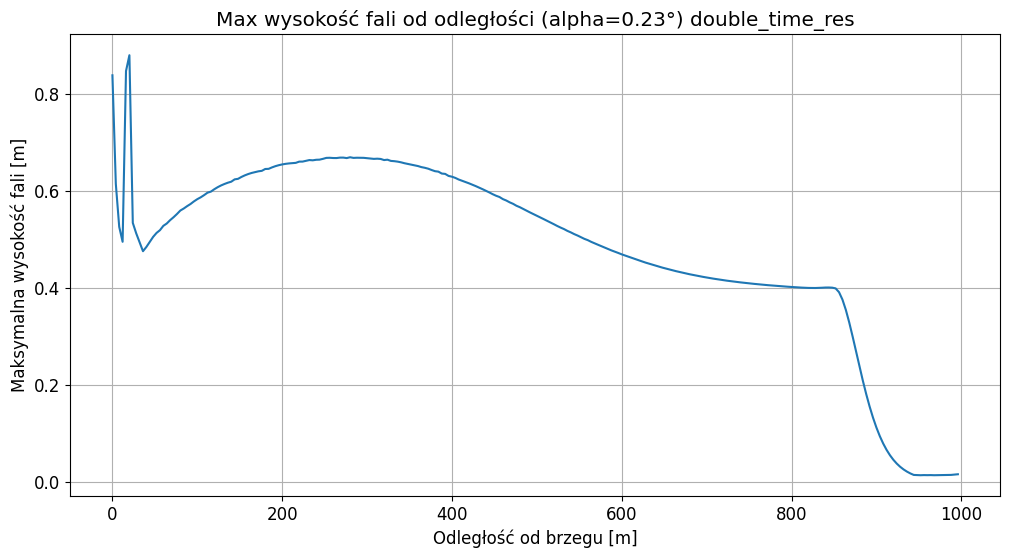

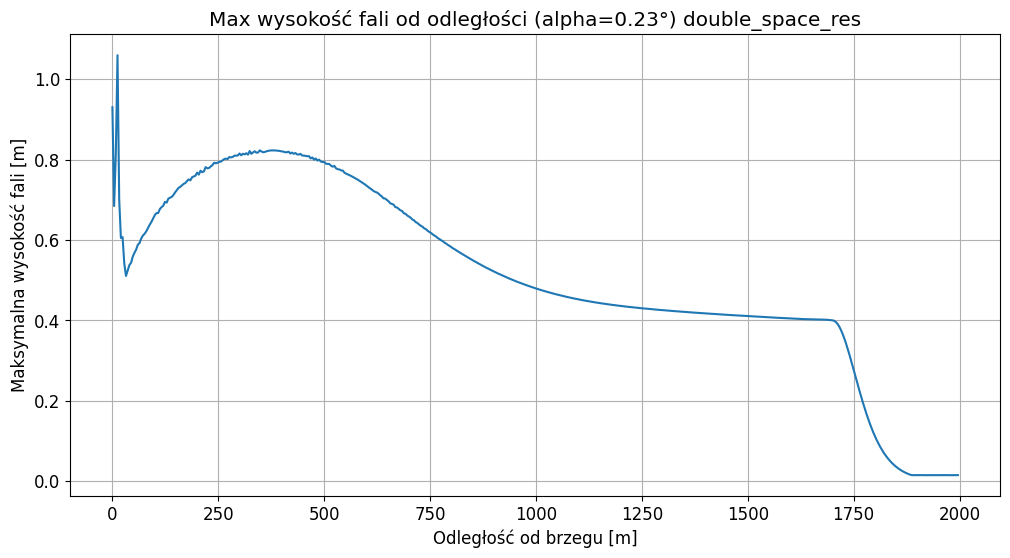

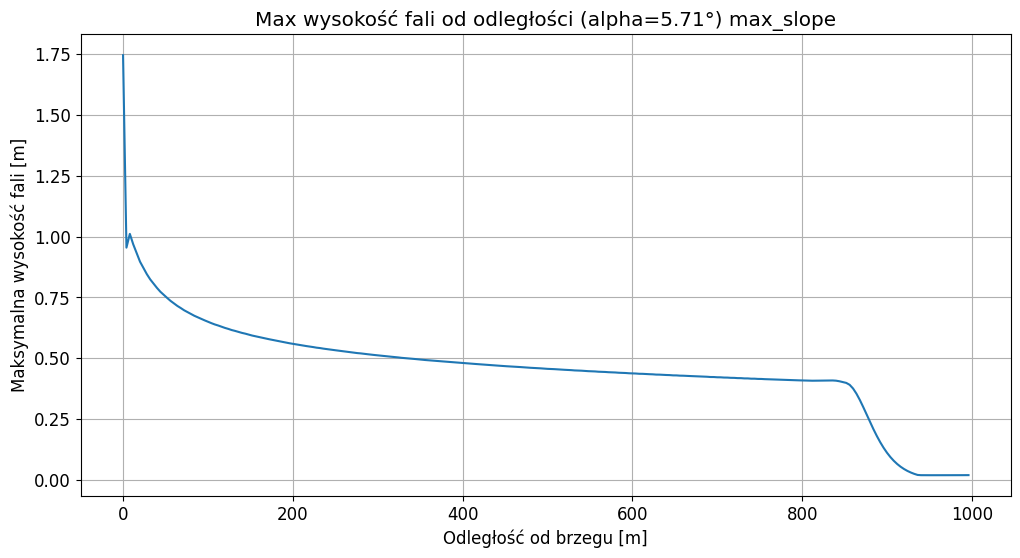

In [ ]:
run_stability_tests()

Jak widać układ jest stabilny numerycznie, dzięki czemu można założyć, że wyniki uzyskane dzięki niemu będą fizyczne dla zadanych założeń.

# Końcowa symulacja i wniosek
Przeprowadzono serię symulacji dla zmiennych głębokości końcowych, co przełożyło się na różne kąty nachylenia dna. Dla każdego przypadku rejestrowano maksymalną wysokość fali w każdym punkcie siatki wzdłuż osi propagacji.

Uruchamianie symulacji końcowej...


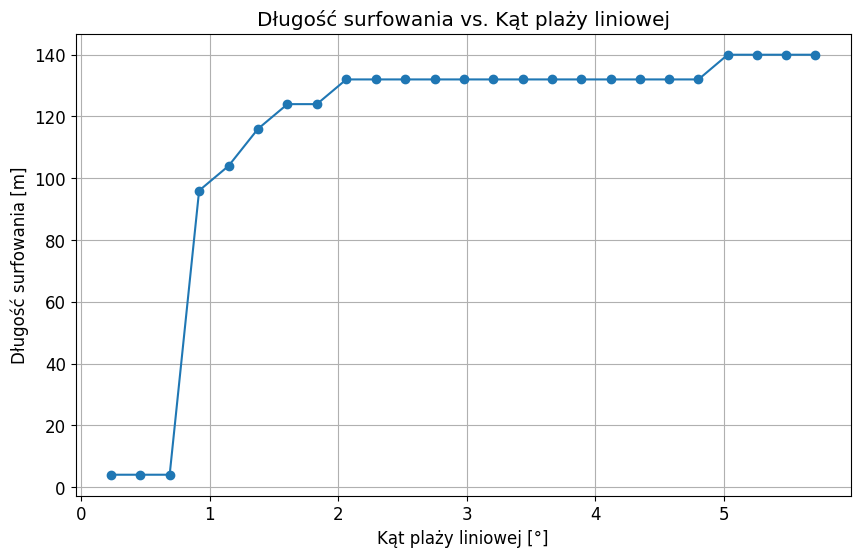

In [ ]:
run_final_simulation()


Jak można zauważyć z powyższego wykresu - dla kątów powyżej około $0.5^\circ C$ długość surfowania nie zależy od kąta nachylenia plaży. Dopiero przy mniejszych kątach badana długość zmniejsza się - może to być wynikiem opisanego wcześńiej dzielenia się fali na mniejsze elementy, któremu to odpowiada załamanie się fali w rzeczywistości, co jest rzeczą porządaną przez surferów.

1] Diederik J. Korteweg and Gustav de Vries. On the change of form of long waves advancing
in a rectangular canal, and on a new type of long stationary waves. Philosophical Magazine,
39(240):422–443, 1895.